# Business Understanding

Jaya Jaya Institut menghadapi permasalahan tingginya angka mahasiswa dropout yang berdampak pada kualitas pendidikan dan reputasi institusi.

## Permasalahan
- Tingginya angka dropout mahasiswa
- Tidak adanya sistem early warning
- Sulit mengidentifikasi faktor utama penyebab dropout

## Tujuan
Membangun model machine learning untuk memprediksi mahasiswa berisiko dropout sehingga institusi dapat melakukan intervensi lebih dini.

## Cakupan
- Data Understanding
- Exploratory Data Analysis
- Data Preparation
- Modeling
- Evaluation
- Deployment

## Import Library

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import joblib

## Load Dataset
Dataset dibaca menggunakan separator ";".

In [9]:
df = pd.read_csv("/content/drive/MyDrive/dicoding/dataset/data_siswa.csv", sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

## Data Cleaning
Menghapus data Enrolled agar model fokus pada klasifikasi Dropout dan Graduate.

In [11]:
df.columns = df.columns.str.strip()
df.rename(columns={'Status': 'target'}, inplace=True)

df = df[df['target'] != 'Enrolled']

df['target'] = df['target'].map({
    'Graduate': 0,
    'Dropout': 1
})

df['target'].value_counts()

,count
target,
0,2209
1,1421


## Distribusi Status Mahasiswa

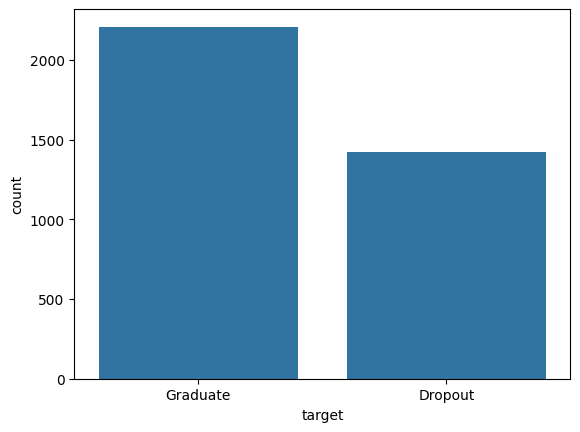

In [12]:
sns.countplot(x='target', data=df)
plt.xticks([0,1], ['Graduate','Dropout'])
plt.show()

### Insight
Mahasiswa dengan status dropout masih memiliki proporsi yang signifikan dibandingkan graduate, sehingga menunjukkan bahwa dropout merupakan masalah nyata yang perlu ditangani secara sistematis oleh institusi.

## Distribusi Umur Mahasiswa

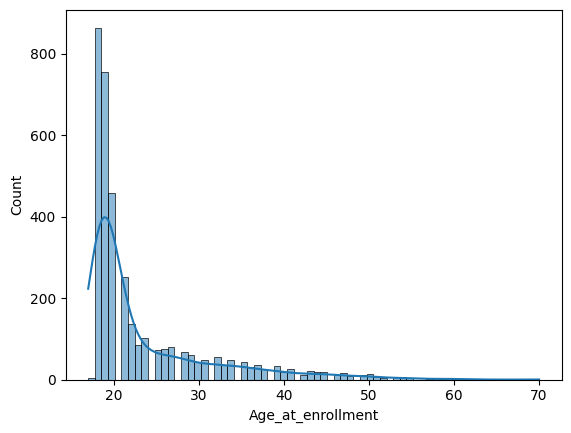

In [13]:
sns.histplot(df['Age_at_enrollment'], kde=True)
plt.show()

### Insight
Sebagian besar mahasiswa berada pada usia awal perkuliahan, namun mahasiswa dengan usia lebih tinggi menunjukkan variasi yang lebih besar dan berpotensi memiliki risiko dropout lebih tinggi akibat faktor eksternal seperti pekerjaan atau tanggung jawab lainnya.

## Distribusi Gender

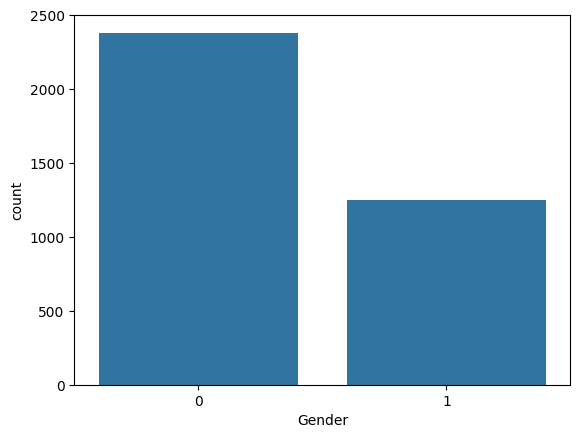

In [14]:
sns.countplot(x='Gender', data=df)
plt.show()

### Insight
Distribusi gender relatif seimbang dan tidak menunjukkan perbedaan signifikan terhadap dropout, sehingga gender bukan faktor utama dalam menentukan keberhasilan studi.

## Admission Grade vs Status

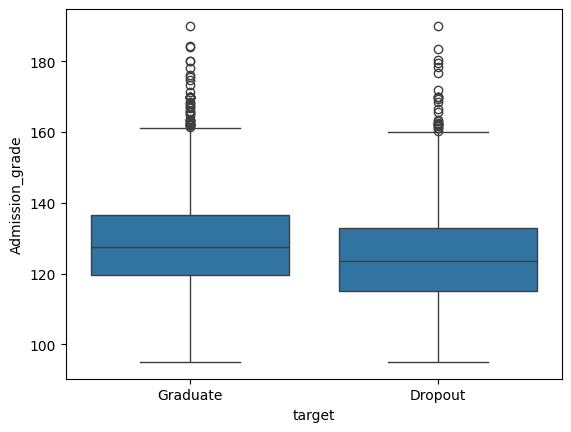

In [15]:
sns.boxplot(x='target', y='Admission_grade', data=df)
plt.xticks([0,1], ['Graduate','Dropout'])
plt.show()

### Insight
Mahasiswa dropout memiliki nilai admission grade yang secara umum lebih rendah dibandingkan graduate, namun terdapat overlap distribusi yang cukup besar sehingga variabel ini tidak menjadi faktor dominan dalam menentukan dropout.

## Status Pembayaran vs Dropout

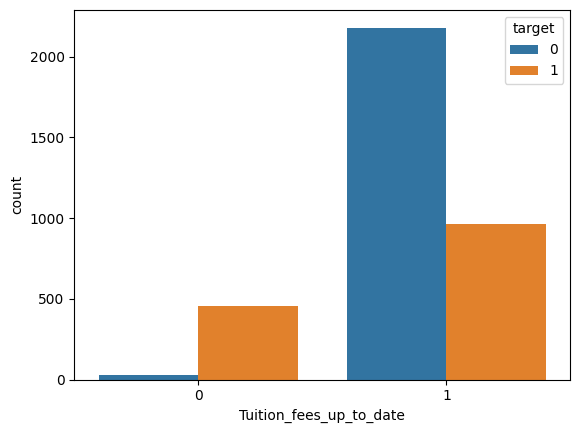

In [16]:
sns.countplot(x='Tuition_fees_up_to_date', hue='target', data=df)
plt.show()

### Insight
Mahasiswa dengan status pembayaran tidak lancar memiliki proporsi dropout yang lebih tinggi secara konsisten dibandingkan mahasiswa yang membayar tepat waktu. Hal ini menunjukkan bahwa faktor finansial merupakan salah satu determinan utama dalam risiko dropout.

## Nilai Semester 1 vs Status

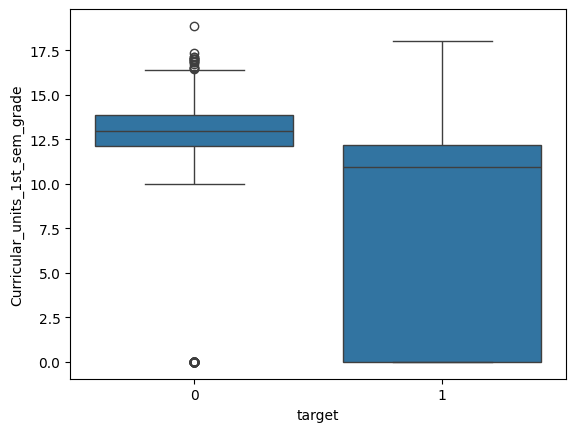

In [17]:
sns.boxplot(x='target', y='Curricular_units_1st_sem_grade', data=df)
plt.show()

### Insight
Mahasiswa dropout memiliki nilai semester pertama yang secara konsisten lebih rendah dibandingkan graduate dengan perbedaan distribusi yang jelas.

Temuan ini menunjukkan bahwa performa akademik pada semester awal dapat digunakan sebagai indikator early warning untuk mengidentifikasi mahasiswa berisiko.

## Mata Kuliah Lulus vs Status

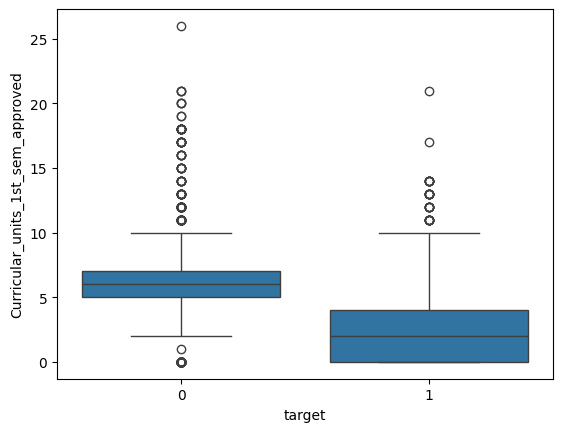

In [18]:
sns.boxplot(x='target', y='Curricular_units_1st_sem_approved', data=df)
plt.show()

### Insight
Mahasiswa yang menyelesaikan lebih sedikit mata kuliah memiliki risiko dropout yang lebih tinggi, yang menunjukkan adanya kesulitan akademik sejak awal masa studi.

## Insight untuk Modeling

Berdasarkan hasil EDA, faktor yang paling berpengaruh terhadap dropout adalah:

- Performa akademik semester awal
- Jumlah mata kuliah yang diselesaikan
- Status pembayaran

Faktor-faktor ini menunjukkan perbedaan distribusi yang jelas antara mahasiswa dropout dan graduate, sehingga digunakan sebagai dasar dalam pemilihan fitur untuk model machine learning.

In [20]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9022038567493113
              precision    recall  f1-score   support

           0       0.90      0.95      0.92       449
           1       0.91      0.82      0.87       277

    accuracy                           0.90       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.90      0.90      0.90       726



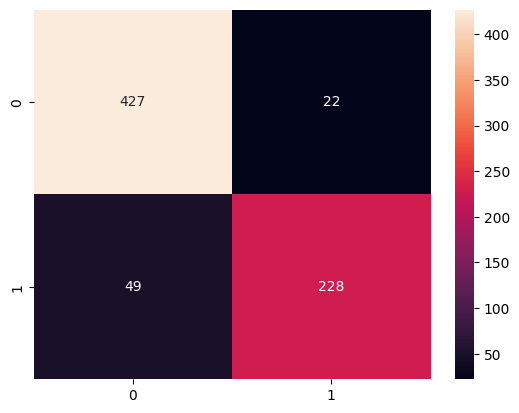

In [23]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

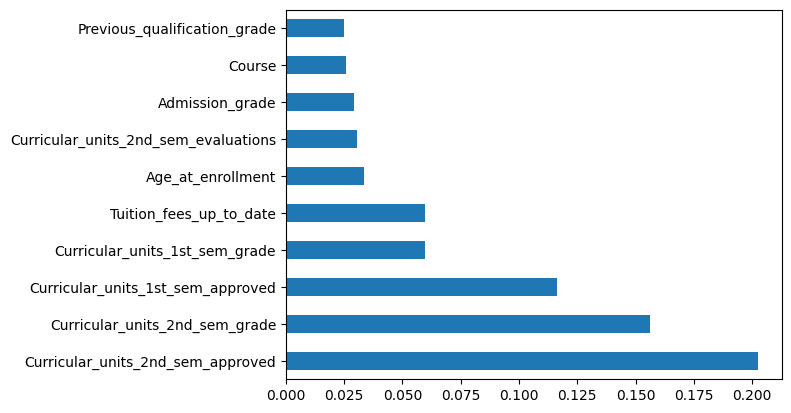

In [24]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.show()

### Insight
Fitur yang paling berpengaruh didominasi oleh performa akademik semester awal dan aktivitas akademik mahasiswa. Hal ini konsisten dengan hasil EDA sebelumnya dan menunjukkan bahwa model berhasil menangkap pola yang relevan dalam data.

In [25]:
joblib.dump(rf, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')

['features.pkl']

## Conclusion

Faktor utama yang mempengaruhi dropout adalah:

- Performa akademik semester awal
- Status pembayaran
- Aktivitas akademik mahasiswa

Admission grade tidak menunjukkan pengaruh dominan berdasarkan hasil analisis.

Temuan ini menunjukkan bahwa institusi dapat mengembangkan sistem early warning berbasis performa akademik dan kondisi finansial mahasiswa.

## Rekomendasi

- Implementasi early warning system berbasis machine learning  
- Monitoring performa akademik sejak semester pertama  
- Program mentoring bagi mahasiswa berisiko  
- Evaluasi kondisi finansial mahasiswa  

## Keterbatasan

Model masih dapat ditingkatkan melalui hyperparameter tuning dan penambahan fitur.